In [1]:
"""
XGBoost 혼잡 임계도달 확률 분류 모델 학습 + 평가 + SHAP 분석
(Model A: segment_key를 X에 포함한 버전 — Model B와의 비교 실험, 빠른 확인용)

입력: output/features/xgb_feature_matrix_v3.parquet
  (v3: v2의 정규 10분 격자+as-of join + is_bottleneck_slot Train 전용
  재계산으로 leakage 제거 - xgb_feature_matrix_ver3.ipynb 참고)

Model A vs Model B:
  Model B(xgb_model.ipynb, 기본/최종 채택)는 segment_key를 X에서 제외한다
  - 90개 카테고리를 트리가 완벽히 구분할 수 있어서, 넣으면 SHAP 설명이
  "이 구간이라서 위험"으로 뭉개지고 실제 원인(공사/네트워크/시간)이
  가려지기 때문이다(output/xgb.md 4.2절, output/feature.md 1절 참고).
  대신 구간의 구조적 특성은 betweenness_*, road_rank, lanes,
  lane_remain_ratio가 대변하도록 설계했다.

  이 노트북(Model A)은 그 설계 결정을 검증하기 위한 비교 실험이다:
  segment_key를 그대로 넣었을 때 성능이 얼마나 더 오르는지를 보면,
  "구조적 피처들이 segment_key가 담던 정보를 얼마나 잘 대변하는지"를
  가늠할 수 있다.

α/threshold: Model B의 값을 그대로 재사용 (빠른 확인용, 탐색 생략)
  Model B는 α×threshold 중첩 grid search(4개 α 후보 × 재학습)로
  (α=0.3, threshold=0.25)를 찾았다. 이 노트북은 segment_key 추가 효과만
  빠르게 보고 싶다는 요청에 따라 그 탐색을 생략하고, Model B가 찾은
  값을 고정으로 재사용한다 - 학습을 1회만 돌면 되므로 훨씬 빠르다.
  대신 "같은 α/threshold 조건에서 segment_key 유무만 다르게" 비교하는
  것이므로, segment_key를 넣었을 때 최적 α/threshold가 달라질 가능성은
  반영하지 못한다(성능 차이가 크게 나오면, 그때 별도로 α/threshold도
  다시 탐색해볼 가치가 있다는 신호로 해석하면 된다).

설계 요약 (Model B와 동일, 사전 합의 사항):
  - 3-class 분류(multi:softprob): 정상(0)/주의(1)/심각(2)
  - Train/Val/Test는 기존 split 컬럼 그대로 사용(시간 기준 분할,
    Prophet과 동일 경계). Test는 최종 평가에만 사용.
  - target_speed는 라벨을 만든 원본값이라 X에서 반드시 제외(leakage).
"""

import json
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, log_loss, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

FEATURE_MATRIX_PATH = "./output/features/xgb_feature_matrix_v3.parquet"
MODEL_DIR = Path("./output/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# 실험 설정
# ------------------------------------------------------------------
RUN_NAME = "v3_modelA_with_segment"   # Model B: "v3_modelB_alpha_threshold_tuned"
INCLUDE_SEGMENT_KEY = True

# Model B가 α×threshold 중첩 탐색으로 찾은 값을 그대로 재사용(재탐색 생략 - 빠른 비교용)
BEST_ALPHA = 0.3
BEST_THRESHOLD = 0.25

BASE_FEATURES = [
    "V_segment", "speed_last_10min", "speed_ma_30min", "speed_ma_1h", "speed_change_rate",
    "hour", "dow", "is_weekend", "is_bottleneck_slot",
    "betweenness_pre", "betweenness_during", "road_rank", "lanes",
    "lane_remain_ratio",
    "incident_flag", "incident_count",
    "precipitation_mm", "is_weather_alert", "is_freezing",
    "y_hat_t30", "y_hat_lower_t30", "y_hat_upper_t30",
]
LABEL_COL = "label"
CLASS_NAMES = ["정상", "주의", "심각"]
SEVERE_CLASS_IDX = 2

print(f"RUN_NAME = {RUN_NAME}, INCLUDE_SEGMENT_KEY = {INCLUDE_SEGMENT_KEY}")
print(f"BEST_ALPHA = {BEST_ALPHA} (Model B 재사용), BEST_THRESHOLD = {BEST_THRESHOLD} (Model B 재사용)")


RUN_NAME = v3_modelA_with_segment, INCLUDE_SEGMENT_KEY = True
BEST_ALPHA = 0.3 (Model B 재사용), BEST_THRESHOLD = 0.25 (Model B 재사용)


In [2]:
# ==================================================================
# 1. 데이터 로드 + 컬럼 정리
# ==================================================================

raw = pl.read_parquet(FEATURE_MATRIX_PATH)
print(f"원본 shape: {raw.shape}")
print(raw.group_by("split").agg(pl.len()).sort("split"))

feature_cols = list(BASE_FEATURES)
if INCLUDE_SEGMENT_KEY:
    feature_cols.append("segment_key")

missing_in_data = [c for c in feature_cols if c not in raw.columns]
if missing_in_data:
    print(f"⚠ 데이터에 없는 피처(스킵): {missing_in_data}")
    feature_cols = [c for c in feature_cols if c in raw.columns]

keep_cols = feature_cols + [LABEL_COL, "split", "segment_key", "timestamp"]
keep_cols = list(dict.fromkeys(keep_cols))  # 중복 제거(순서 유지)

df = raw.select(keep_cols).to_pandas()

# ⚠ is_weather_alert/is_freezing은 날씨 조인 경계에서 결측(528건)이 섞여 있어
# pandas가 bool이 아니라 object dtype으로 읽는다(None/True/False 혼재).
# select_dtypes(include="bool")로는 못 잡으므로, 불린 성격 컬럼을 명시적으로
# 나열해서 결측=False로 채운 뒤 int8로 캐스팅한다.
BOOL_LIKE_COLS = ["is_weekend", "is_bottleneck_slot", "incident_flag", "is_weather_alert", "is_freezing"]
for c in BOOL_LIKE_COLS:
    if c in df.columns:
        df[c] = df[c].astype("boolean").fillna(False).astype("int8")

if INCLUDE_SEGMENT_KEY:
    df["segment_key"] = df["segment_key"].astype("category")

print(f"최종 피처 수: {len(feature_cols)}")
print(feature_cols)
print()
print("dtype 확인(object가 남아있으면 안 됨):")
print(df[feature_cols].dtypes.value_counts())


원본 shape: (8068423, 28)
shape: (3, 2)
┌───────┬─────────┐
│ split ┆ len     │
│ ---   ┆ ---     │
│ str   ┆ u32     │
╞═══════╪═════════╡
│ Test  ┆ 51660   │
│ Train ┆ 7836853 │
│ Val   ┆ 179910  │
└───────┴─────────┘
최종 피처 수: 23
['V_segment', 'speed_last_10min', 'speed_ma_30min', 'speed_ma_1h', 'speed_change_rate', 'hour', 'dow', 'is_weekend', 'is_bottleneck_slot', 'betweenness_pre', 'betweenness_during', 'road_rank', 'lanes', 'lane_remain_ratio', 'incident_flag', 'incident_count', 'precipitation_mm', 'is_weather_alert', 'is_freezing', 'y_hat_t30', 'y_hat_lower_t30', 'y_hat_upper_t30', 'segment_key']

dtype 확인(object가 남아있으면 안 됨):
float64     12
int8         7
int64        3
category     1
Name: count, dtype: int64


In [3]:
df

,V_segment,speed_last_10min,speed_ma_30min,speed_ma_1h,speed_change_rate,hour,dow,is_weekend,is_bottleneck_slot,betweenness_pre,...,precipitation_mm,is_weather_alert,is_freezing,y_hat_t30,y_hat_lower_t30,y_hat_upper_t30,segment_key,label,split,timestamp
0,37.283890,37.283890,37.283890,37.283890,0.000000,0,1,0,0,0.021732,...,NaN,0,0,37.024166,30.414237,43.944241,SEG_01_201_202_AB,0,Train,2024-10-01 00:00:00
1,35.902136,36.887653,37.019732,37.019732,0.000000,0,1,0,0,0.021732,...,NaN,0,0,37.319556,30.242161,44.182774,SEG_01_201_202_AB,0,Train,2024-10-01 00:10:00
2,36.389911,36.284801,36.725760,36.725760,0.000000,0,1,0,0,0.021732,...,NaN,0,0,37.608379,30.211607,44.888109,SEG_01_201_202_AB,0,Train,2024-10-01 00:20:00
3,37.561794,37.051197,36.741217,36.818742,-0.077525,0,1,0,0,0.021732,...,NaN,0,0,37.890540,30.749515,45.119347,SEG_01_201_202_AB,0,Train,2024-10-01 00:30:00
4,35.801654,36.318069,36.551356,36.707481,-0.156125,0,1,0,0,0.021732,...,NaN,0,0,38.165830,31.056012,45.211368,SEG_01_201_202_AB,0,Train,2024-10-01 00:40:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8068418,36.252973,36.928813,34.208024,35.055559,-0.847535,22,2,0,0,0.013227,...,0.0,0,0,NaN,NaN,NaN,SEG_45_233_245_BA,0,Test,2026-07-01 22:50:00
8068419,37.283849,38.622922,35.869865,36.498229,-0.628364,23,2,0,0,0.013227,...,0.0,0,0,NaN,NaN,NaN,SEG_45_233_245_BA,0,Test,2026-07-01 23:00:00
8068420,37.521750,37.402799,37.725044,36.718187,1.006857,23,2,0,0,0.013227,...,0.0,0,0,NaN,NaN,NaN,SEG_45_233_245_BA,0,Test,2026-07-01 23:10:00
8068421,35.530724,35.530724,37.310258,35.891302,1.418957,23,2,0,0,0.013227,...,0.0,0,0,NaN,NaN,NaN,SEG_45_233_245_BA,0,Test,2026-07-01 23:20:00


In [4]:
# ==================================================================
# 2. Train/Val/Test 분할
# ==================================================================

train_df = df[df["split"] == "Train"].reset_index(drop=True)
val_df = df[df["split"] == "Val"].reset_index(drop=True)
test_df = df[df["split"] == "Test"].reset_index(drop=True)

X_train, y_train = train_df[feature_cols], train_df[LABEL_COL]
X_val, y_val = val_df[feature_cols], val_df[LABEL_COL]
X_test, y_test = test_df[feature_cols], test_df[LABEL_COL]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("\nTrain 라벨 분포:")
print(y_train.value_counts(normalize=True).sort_index())

Train: (7836853, 23), Val: (179910, 23), Test: (51660, 23)

Train 라벨 분포:
label
0    0.906806
1    0.072095
2    0.021100
Name: proportion, dtype: float64


In [5]:
# ==================================================================
# 3. 클래스 가중치 (BEST_ALPHA=0.3 고정) + 헬퍼 함수
# ==================================================================

base_class_weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
print("balanced 클래스 가중치(α=1 기준):")
for c, w in zip([0, 1, 2], base_class_weights):
    print(f"  {CLASS_NAMES[c]}(class={c}): {w:.3f}")

sample_weight = (base_class_weights**BEST_ALPHA)[y_train.values]


def predict_with_threshold(proba: np.ndarray, threshold_severe: float) -> np.ndarray:
    """심각 확률이 threshold_severe 이상이면 심각(2), 아니면 정상/주의 중 argmax"""
    return np.where(proba[:, SEVERE_CLASS_IDX] >= threshold_severe, SEVERE_CLASS_IDX, np.argmax(proba[:, :2], axis=1))


balanced 클래스 가중치(α=1 기준):
  정상(class=0): 0.368
  주의(class=1): 4.624
  심각(class=2): 15.798


In [6]:
# ==================================================================
# 4. 단일 학습 (α/threshold 탐색 생략, Model B 값 재사용 - 빠른 비교용)
# ==================================================================

model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    enable_categorical=INCLUDE_SEGMENT_KEY,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], verbose=False)

print(f"학습 완료 (alpha={BEST_ALPHA}, threshold={BEST_THRESHOLD})")
print(f"best_iteration: {model.best_iteration}")

model.save_model(MODEL_DIR / f"{RUN_NAME}.json")
print(f"모델 저장: {(MODEL_DIR / f'{RUN_NAME}.json').resolve()}")


KeyboardInterrupt: 

In [ ]:
# ==================================================================
# 5. 평가: 전체 지표 (Train/Val/Test) - 튜닝된 threshold 적용
# ==================================================================

def evaluate(name, X, y):
    proba = model.predict_proba(X)
    pred = predict_with_threshold(proba, BEST_THRESHOLD)
    report = classification_report(
        y, pred, labels=[0, 1, 2], target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y, pred, labels=[0, 1, 2])
    ll = log_loss(y, proba, labels=[0, 1, 2])

    print(f"=== {name} (alpha={BEST_ALPHA}, threshold={BEST_THRESHOLD:.2f}) ===")
    print(classification_report(y, pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))
    print(f"log_loss: {ll:.4f}")
    print(f"심각(class=2) Recall: {report['심각']['recall']:.4f}, Precision: {report['심각']['precision']:.4f}")
    print(f"Confusion Matrix (행=실제, 열=예측, 순서=정상/주의/심각):\n{cm}")
    print()
    return {"report": report, "confusion_matrix": cm.tolist(), "log_loss": ll}

metrics = {
    "train": evaluate("Train", X_train, y_train),
    "val": evaluate("Val", X_val, y_val),
    "test": evaluate("Test", X_test, y_test),
}


=== Train (alpha=0.3, threshold=0.25) ===
              precision    recall  f1-score   support

          정상       0.97      0.96      0.97   7106502
          주의       0.55      0.51      0.53    564997
          심각       0.47      0.80      0.59    165354

    accuracy                           0.93   7836853
   macro avg       0.67      0.76      0.70   7836853
weighted avg       0.93      0.93      0.93   7836853

log_loss: 0.1609
심각(class=2) Recall: 0.7978, Precision: 0.4699
Confusion Matrix (행=실제, 열=예측, 순서=정상/주의/심각):
[[6857684  210033   38785]
 [ 166076  288918  110003]
 [  10660   22778  131916]]

=== Val (alpha=0.3, threshold=0.25) ===
              precision    recall  f1-score   support

          정상       0.94      0.91      0.93    144241
          주의       0.48      0.44      0.46     24572
          심각       0.46      0.76      0.57     11097

    accuracy                           0.84    179910
   macro avg       0.63      0.70      0.65    179910
weighted avg       0.

In [ ]:
# ==================================================================
# 6. 구간별 심각(class=2) Recall (편중 구간 성능 별도 확인) - 튜닝된 threshold 적용
# ==================================================================

test_pred = predict_with_threshold(model.predict_proba(X_test), BEST_THRESHOLD)
seg_eval = test_df[["segment_key"]].copy()
seg_eval["y_true"] = y_test.values
seg_eval["y_pred"] = test_pred

severe_actual = seg_eval[seg_eval["y_true"] == 2]
seg_recall = (
    severe_actual.groupby("segment_key")
    .apply(lambda g: pd.Series({"n_severe": len(g), "recall": (g["y_pred"] == 2).mean()}), include_groups=False)
    .sort_values("n_severe", ascending=False)
)

print(f"Test 심각 사례가 있는 구간 수: {seg_recall.shape[0]}")
print("\n심각 사례 많은 구간 상위 10개 Recall:")
print(seg_recall.head(10))

seg_recall.to_csv(MODEL_DIR / f"{RUN_NAME}_segment_severe_recall.csv", encoding="utf-8-sig")


Test 심각 사례가 있는 구간 수: 66

심각 사례 많은 구간 상위 10개 Recall:
                   n_severe    recall
segment_key                          
SEG_02_202_203_BA     307.0  0.947883
SEG_06_206_207_BA     276.0  0.909420
SEG_03_203_204_BA     260.0  0.926923
SEG_06_206_207_AB     196.0  0.872449
SEG_09_209_210_AB     162.0  0.716049
SEG_23_223_224_AB     135.0  0.940741
SEG_01_201_202_BA     123.0  0.886179
SEG_24_224_225_BA      84.0  0.619048
SEG_37_237_238_BA      82.0  0.865854
SEG_05_205_206_AB      79.0  0.822785


In [ ]:
# ==================================================================
# 7. 메트릭 저장 (버전 비교용)
# ==================================================================

summary = {
    "run_name": RUN_NAME,
    "include_segment_key": INCLUDE_SEGMENT_KEY,
    "feature_matrix": FEATURE_MATRIX_PATH,
    "n_features": len(feature_cols),
    "features": feature_cols,
    "best_alpha": BEST_ALPHA,
    "best_threshold": BEST_THRESHOLD,
    "alpha_threshold_source": "Model B(v3_modelB_alpha_threshold_tuned) 재사용 - 재탐색 안 함",
    "best_iteration": int(model.best_iteration),
    "test_severe_recall": metrics["test"]["report"]["심각"]["recall"],
    "test_severe_precision": metrics["test"]["report"]["심각"]["precision"],
    "test_macro_f1": metrics["test"]["report"]["macro avg"]["f1-score"],
    "test_accuracy": metrics["test"]["report"]["accuracy"],
    "test_log_loss": metrics["test"]["log_loss"],
    "val_severe_recall": metrics["val"]["report"]["심각"]["recall"],
    "val_severe_precision": metrics["val"]["report"]["심각"]["precision"],
}

with open(MODEL_DIR / f"{RUN_NAME}_metrics.json", "w", encoding="utf-8") as f:
    json.dump({**summary, "detail": metrics}, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print(f"\n저장 완료: {(MODEL_DIR / f'{RUN_NAME}_metrics.json').resolve()}")


In [ ]:
# ==================================================================
# 7b. 이진 집계 지표: "병목(주의+심각) 발생 여부" 관점
# ==================================================================
# 3-class 구조/모델을 그대로 유지한 채, 이미 나온 예측(predict_with_threshold
# 결과)을 "정상 vs 위험(주의+심각)"으로 다시 묶어서 본 것 - 재학습/재튜닝
# 없이 기존 예측을 다른 각도로 집계만 한다.
# 목적: 3-class 세분류 성능과 별개로, "정상이 아닌 상황을 얼마나 놓치지
# 않고 잡아내는가"라는 더 단순한 질문에 대한 답을 같이 제시하기 위함.

def evaluate_binary(name, X, y):
    proba = model.predict_proba(X)
    pred = predict_with_threshold(proba, BEST_THRESHOLD)
    y_bin = (y.values != 0).astype(int)
    pred_bin = (pred != 0).astype(int)
    p = precision_score(y_bin, pred_bin, zero_division=0)
    r = recall_score(y_bin, pred_bin, zero_division=0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    cm = confusion_matrix(y_bin, pred_bin, labels=[0, 1])
    print(f"=== {name}: 위험(주의+심각) vs 정상 ===")
    print(f"Precision={p:.4f}, Recall={r:.4f}, F1={f1:.4f}")
    print(f"Confusion Matrix (행=실제, 열=예측, 순서=정상/위험):\n{cm}")
    print()
    return {"precision": p, "recall": r, "f1": f1, "confusion_matrix": cm.tolist()}

binary_metrics = {
    "train": evaluate_binary("Train", X_train, y_train),
    "val": evaluate_binary("Val", X_val, y_val),
    "test": evaluate_binary("Test", X_test, y_test),
}

with open(MODEL_DIR / f"{RUN_NAME}_binary_risk_metrics.json", "w", encoding="utf-8") as f:
    json.dump(binary_metrics, f, ensure_ascii=False, indent=2, default=str)

print(f"저장 완료: {(MODEL_DIR / f'{RUN_NAME}_binary_risk_metrics.json').resolve()}")


기록된 라운드 수: 1000


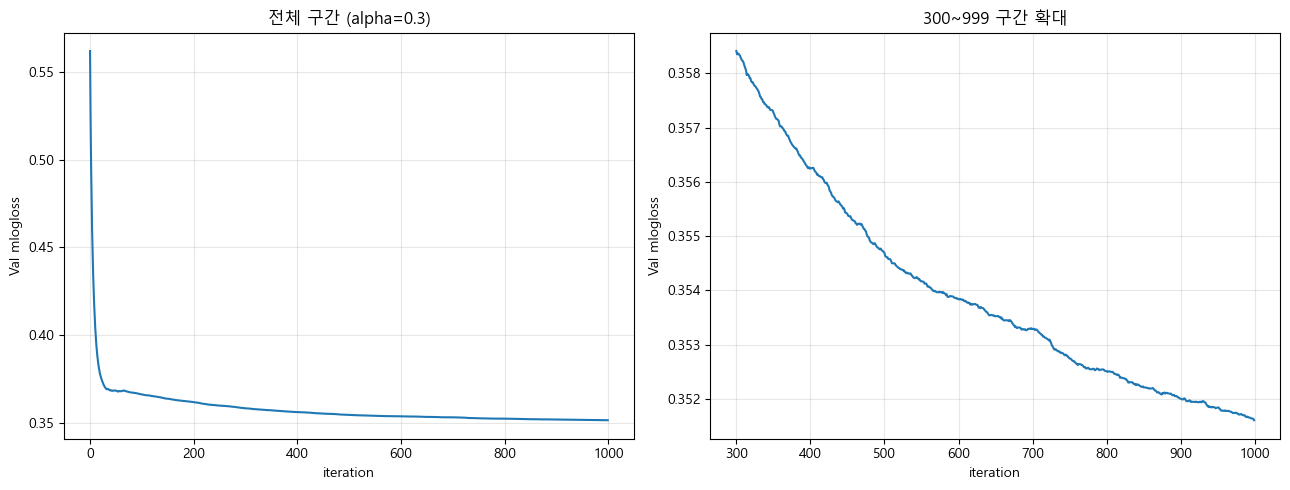


iteration별 Val mlogloss:
  iter    0: 0.56188
  iter   50: 0.36845
  iter  100: 0.36637
  iter  200: 0.36188
  iter  300: 0.35841
  iter  400: 0.35625
  iter  500: 0.35469
  iter  600: 0.35384
  iter  700: 0.35329
  iter  800: 0.35251
  iter  900: 0.35200
  iter  999: 0.35160

0→300 구간 개선폭: 0.20346 (36.2%)
300→999 구간 개선폭: 0.00681 (1.9%)
700→999 구간(마지막 300라운드) 개선폭: 0.00168 (0.5%)

판단: 마지막 300라운드 개선폭이 1% 미만 -> 사실상 평평, 1000트리까지 갈 필요 없었을 가능성 높음


In [ ]:
# ==================================================================
# 4b. 선택된 모델(alpha=0.3)의 학습 곡선 확인
# ==================================================================
# best_iteration=999(=n_estimators 상한)가 진짜 "아직도 개선 중"이라 그런 건지,
# 아니면 "이미 평평한데 미세한 잡음 때문에 early stopping이 안 걸린 것"뿐인지
# evals_result()로 확인한다. eval_set=[(X_val, y_val)] 하나만 넘겼으므로
# 키는 "validation_0".

import matplotlib.pyplot as plt

evals_result = model.evals_result()
val_mlogloss = evals_result["validation_0"]["mlogloss"]
n_rounds = len(val_mlogloss)
print(f"기록된 라운드 수: {n_rounds}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(val_mlogloss)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("Val mlogloss")
axes[0].set_title(f"전체 구간 (alpha={BEST_ALPHA})")
axes[0].grid(alpha=0.3)

zoom_start = min(300, n_rounds - 1)
axes[1].plot(range(zoom_start, n_rounds), val_mlogloss[zoom_start:])
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("Val mlogloss")
axes[1].set_title(f"{zoom_start}~{n_rounds - 1} 구간 확대")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / f"{RUN_NAME}_learning_curve.png", dpi=120)
plt.show()

# ------------------------------------------------------------------
# 정량적 판단: 구간별 개선폭(절대/상대)
# ------------------------------------------------------------------
checkpoints = [c for c in [0, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900] if c < n_rounds] + [n_rounds - 1]
print("\niteration별 Val mlogloss:")
for it in checkpoints:
    print(f"  iter {it:4d}: {val_mlogloss[it]:.5f}")

late_start = min(300, n_rounds - 1)
tail_start = min(700, n_rounds - 1)
early_gain = val_mlogloss[0] - val_mlogloss[late_start]
late_gain = val_mlogloss[late_start] - val_mlogloss[-1]
tail_gain = val_mlogloss[tail_start] - val_mlogloss[-1]

print(f"\n0→{late_start} 구간 개선폭: {early_gain:.5f} ({early_gain / val_mlogloss[0]:.1%})")
print(f"{late_start}→{n_rounds - 1} 구간 개선폭: {late_gain:.5f} ({late_gain / val_mlogloss[late_start]:.1%})")
print(f"{tail_start}→{n_rounds - 1} 구간(마지막 300라운드) 개선폭: {tail_gain:.5f} ({tail_gain / val_mlogloss[tail_start]:.1%})")

if tail_gain / val_mlogloss[tail_start] < 0.01:
    print("\n판단: 마지막 300라운드 개선폭이 1% 미만 -> 사실상 평평, 1000트리까지 갈 필요 없었을 가능성 높음")
else:
    print("\n판단: 마지막 300라운드도 1% 이상 개선 -> 800만 행 규모에서 1000트리가 실제로 유의미했을 가능성")


In [ ]:
# ==================================================================
# 8. SHAP 분석용 샘플 추출 (Test 셋에서 클래스 층화추출)
# ==================================================================

import shap

SHAP_SAMPLE_PER_CLASS = 5000  # 클래스당 최대 샘플 수(전량 계산 비용 절감)

shap_idx = []
for c in [0, 1, 2]:
    idx_c = test_df.index[y_test == c]
    n = min(len(idx_c), SHAP_SAMPLE_PER_CLASS)
    shap_idx.extend(np.random.RandomState(42).choice(idx_c, size=n, replace=False))

X_shap = X_test.loc[shap_idx]
print(f"SHAP 샘플 크기: {X_shap.shape} (클래스별 최대 {SHAP_SAMPLE_PER_CLASS}개)")

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap)  # shape: (n_samples, n_features, n_classes)
print(f"shap_values shape: {shap_values.values.shape}")

SHAP 샘플 크기: (12971, 22) (클래스별 최대 5000개)
shap_values shape: (12971, 22, 3)


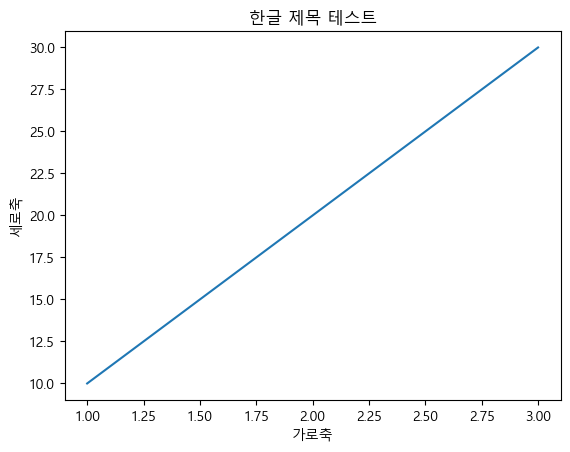

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕

# 마이너스(-) 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

# 테스트 그래프
x = [1, 2, 3]
y = [10, 20, 30]

plt.plot(x, y)
plt.title("한글 제목 테스트")
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

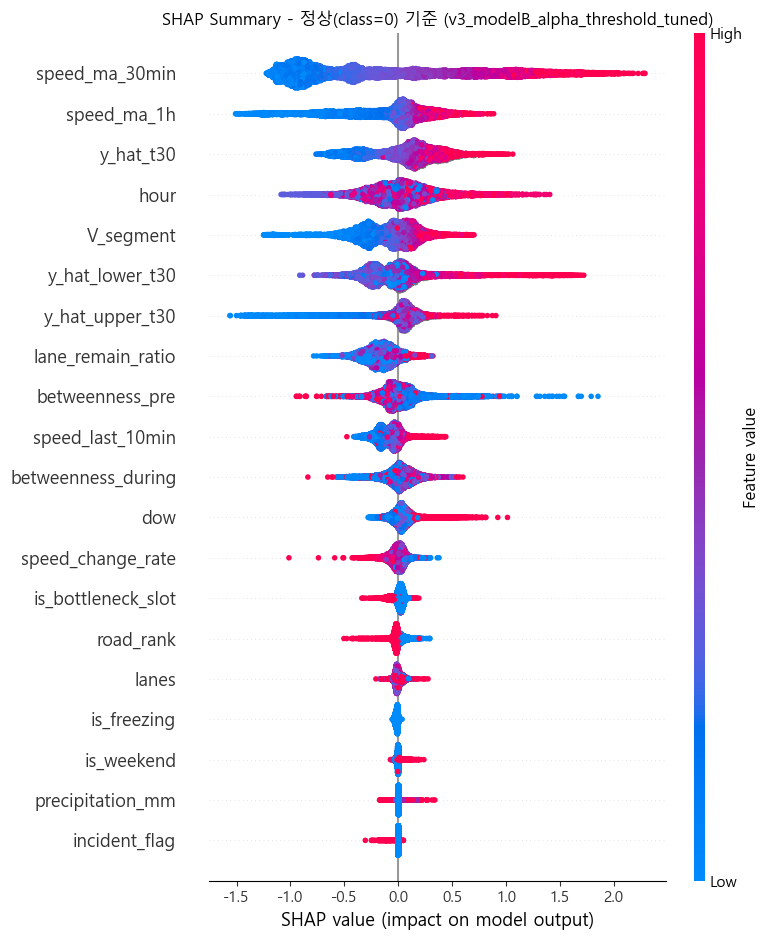

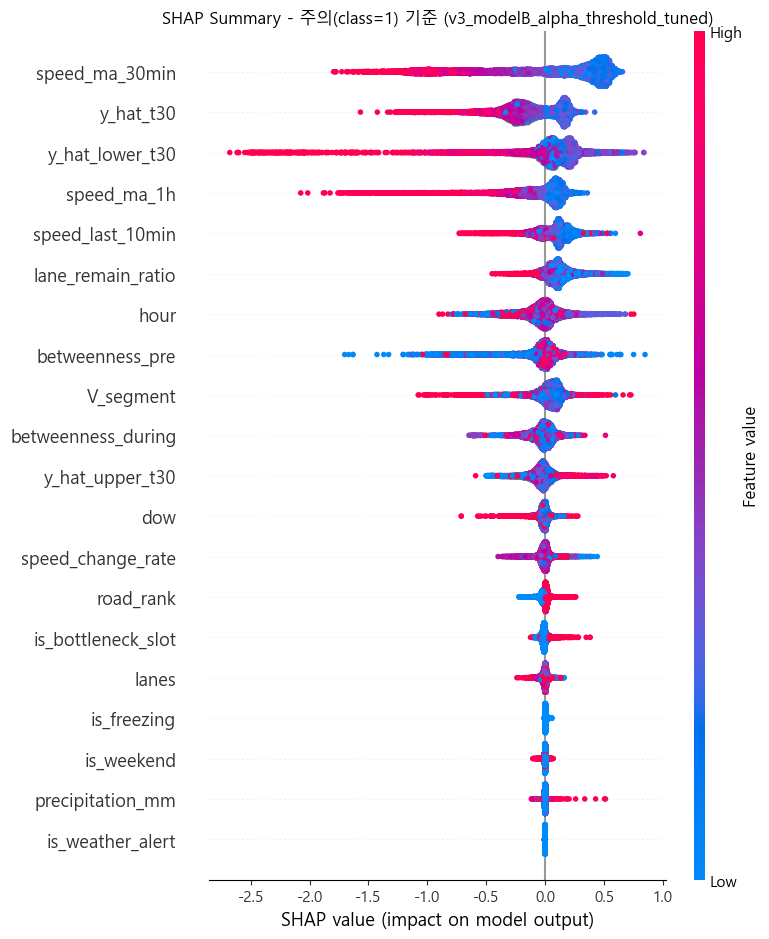

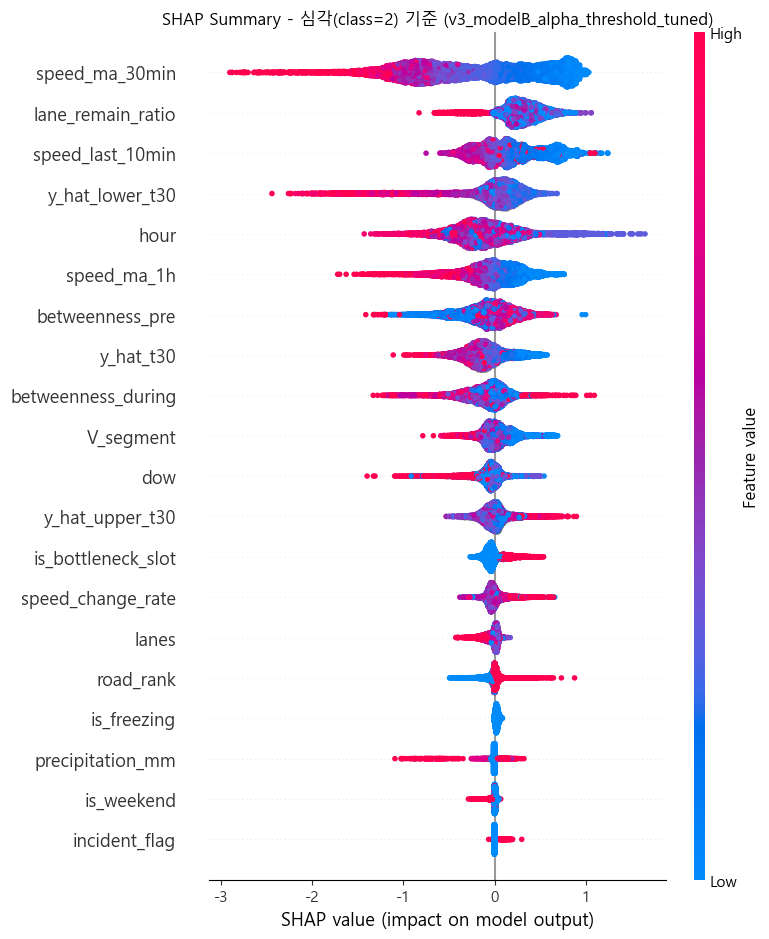


정상 기준 상위 10개 피처:
class           feature  mean_abs_shap
   정상    speed_ma_30min       0.742385
   정상       speed_ma_1h       0.299731
   정상         y_hat_t30       0.261831
   정상              hour       0.228670
   정상         V_segment       0.213316
   정상   y_hat_lower_t30       0.211996
   정상   y_hat_upper_t30       0.176862
   정상 lane_remain_ratio       0.176203
   정상   betweenness_pre       0.130743
   정상  speed_last_10min       0.107404

주의 기준 상위 10개 피처:
class            feature  mean_abs_shap
   주의     speed_ma_30min       0.467876
   주의          y_hat_t30       0.224316
   주의    y_hat_lower_t30       0.213759
   주의        speed_ma_1h       0.189295
   주의   speed_last_10min       0.127857
   주의  lane_remain_ratio       0.121703
   주의               hour       0.121213
   주의    betweenness_pre       0.105150
   주의          V_segment       0.090445
   주의 betweenness_during       0.069971

심각 기준 상위 10개 피처:
class            feature  mean_abs_shap
   심각     speed_ma_30min       0.6628

In [ ]:
# ==================================================================
# 9. SHAP summary plot - 클래스별로 각각 하나씩 + 클래스별 중요도 표
# ==================================================================

import matplotlib.pyplot as plt

for class_idx, class_name in enumerate(CLASS_NAMES):
    shap.summary_plot(shap_values[:, :, class_idx], X_shap, show=False)
    plt.title(f"SHAP Summary - {class_name}(class={class_idx}) 기준 ({RUN_NAME})")
    plt.tight_layout()
    plt.savefig(MODEL_DIR / f"{RUN_NAME}_shap_{class_name}.png", dpi=120)
    plt.show()
    plt.close()

# 클래스별 mean(|SHAP|) 중요도 테이블
importance_rows = []
for c, cname in enumerate(CLASS_NAMES):
    mean_abs = np.abs(shap_values.values[:, :, c]).mean(axis=0)
    for feat, val in zip(feature_cols, mean_abs):
        importance_rows.append({"class": cname, "feature": feat, "mean_abs_shap": val})

importance_df = pd.DataFrame(importance_rows)
importance_df.to_csv(MODEL_DIR / f"{RUN_NAME}_shap_importance.csv", index=False, encoding="utf-8-sig")

for cname in CLASS_NAMES:
    print(f"\n{cname} 기준 상위 10개 피처:")
    print(
        importance_df[importance_df["class"] == cname]
        .sort_values("mean_abs_shap", ascending=False)
        .head(10)
        .to_string(index=False)
    )


In [ ]:
# ==================================================================
# 10. 개별 예측 1건에 대한 top-k SHAP 기여 피처 (대시보드 출력 스펙용)
# ==================================================================
# 원래 파이프라인 산출 스펙의 "top_shap_features"에 대응하는 헬퍼.


def get_top_shap_features(row_idx: int, class_idx: int = SEVERE_CLASS_IDX, k: int = 3):
    contributions = shap_values.values[row_idx, :, class_idx]
    order = np.argsort(-np.abs(contributions))[:k]
    return [
        {"feature": feature_cols[i], "contribution": round(float(contributions[i]), 4)}
        for i in order
    ]


# 예시: 심각으로 예측된 샘플 하나 확인
example_idx = 0
example_row = X_shap.iloc[example_idx]
print(f"예시 row (segment_key={test_df.loc[X_shap.index[example_idx], 'segment_key']}):")
print(f"top_shap_features (심각 기준): {get_top_shap_features(example_idx)}")

예시 row (segment_key=SEG_12_212_213_BA):
top_shap_features (심각 기준): [{'feature': 'hour', 'contribution': -0.7044}, {'feature': 'speed_ma_30min', 'contribution': -0.6526}, {'feature': 'betweenness_during', 'contribution': -0.6419}]


In [ ]:
"""
Model A(segment_key 포함) 비교 실험 노트

이 노트북은 α/threshold 재탐색을 생략하고 Model B가 찾은 값
(α=0.3, threshold=0.25)을 그대로 재사용한 빠른 비교용이다.
segment_key를 넣었을 때 실제로 최적 α/threshold도 달라지는지까지
보려면, xgb_model.ipynb의 x4train처럼 α×threshold 중첩 탐색 코드를
다시 넣고 ALPHA_GRID/THRESHOLD_GRID를 정의해서 돌리면 된다.

버전 비교: output/models/v3_modelA_with_segment_metrics.json 과
output/models/v3_modelB_alpha_threshold_tuned_metrics.json 을
나란히 비교하면 된다(test_severe_recall, test_severe_precision,
test_macro_f1 등).
"""
print("완료")
